# Ejercicio 1.

#### Mediante método gráfico, resuelva el siguiente problema de optimización lineal:
$$min z = x^2 + y^2 + 4xy$$

#### Sujeto a las restricciones:
$$x^2 + 7y^2 \leq 4$$
$$x + y \geq 1$$
$$x \geq 0$$
$$y \geq 0$$


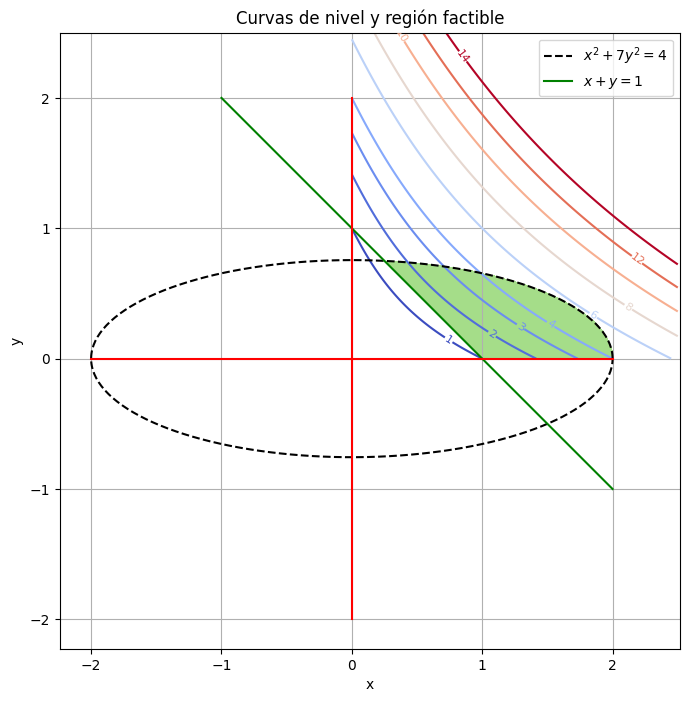

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Crear malla
x = np.linspace(0, 2.5, 400)
y = np.linspace(0, 2.5, 400)
X, Y = np.meshgrid(x, y)

# Función objetivo
Z = X**2 + Y**2 + 4*X*Y

# Restricciones
g1 = X**2 + 7*Y**2 <= 4        # Círculo
g2 = X + Y >= 1                # Semirrecta
g3 = (X >= 0) & (Y >= 0)       # Primer cuadrante
factible = g1 & g2 & g3        # Región factible

# Crear figura
plt.figure(figsize=(8, 8))

# Dibujar curvas de nivel
contours = plt.contour(X, Y, Z, levels=[1, 2, 3, 4, 6, 8, 10, 12, 14], cmap='coolwarm')
plt.clabel(contours, inline=True, fontsize=8)

# Sombrear región factible
plt.contourf(X, Y, factible, levels=[0.5, 1], colors=["#4dbc15"], alpha=0.5)

# Dibujar fronteras de las restricciones
theta = np.linspace(0, 2*np.pi, 300)
plt.plot(2*np.cos(theta), 2*np.sin(theta)/(7**(1/2)), 'k--', label='$x^2 + 7y^2 = 4$')  # círculo
plt.plot([-1, 2], [2, -1], 'g-', label='$x + y = 1$')                    # recta
plt.plot([-2, 2], [0,0], 'r-')                    # recta
plt.plot([0,0], [-2,2], 'r-')                    # recta
# Configurar gráfica
plt.xlabel('x')
plt.ylabel('y')
plt.title('Curvas de nivel y región factible')
plt.xlim(0, 2.5)
plt.ylim(0, 2.5)
plt.grid(True)
plt.legend()
plt.axis('equal')

plt.show()

# Ejercicio 2

#### Se le entrega el siguiente problema de optimización para una función $f(x, y)$, con las restricciones $g_i$ con $i = {1, 2, 3, 4, 5}$, resuelva mediante el método de KKT.

### Objetivo:

$$
min f(x, y) = x^4 + y^4 - 4xy^4 + 4x^2 + y^2
$$

### Sujeto a:

\begin{cases}
g_1(x, y) = x + y - 3 \leq 0\\
g_2(x, y) = x^2 + y^2 - 4 \leq 0\\
g_3(x, y) = x^2 - y \leq 0\\
g_4(x) = x \geq 0\\
g_5(y) = y \geq 0
\end{cases}


Para un mejor entendimiento:

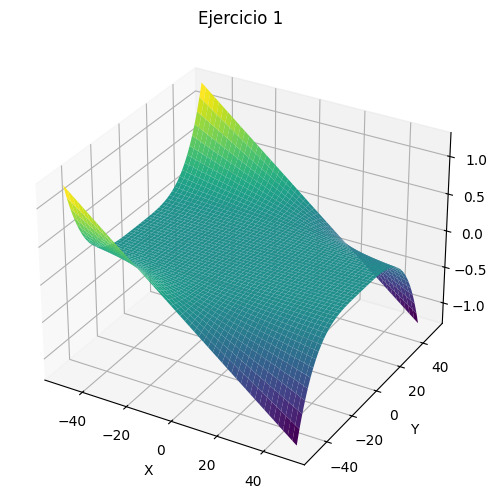

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.close('all')

fx = lambda x, y: x**4 + y**4 - 4*x*y**4 + 4*x**2 + y**2

x = np.linspace(-50, 50, 500)
y = np.linspace(-50, 50, 500)

X, Y = np.meshgrid(x, y)
Z = fx(X, Y)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Ejercicio 1')

plt.show()

## Desarrollo.

#### primero, hacemos el lagrangiano:
* $$ L(x, y, \lambda_i) = f(x, y) + \lambda_1 * g_1(x, y)+ \lambda_2 * g_2(x, y)+ \lambda_3 * g_3(x, y)+ \lambda_4 * g_4(x)+ \lambda_5 * g_5(y)$$
* $$ L(x, y, \lambda_i) = x^4 + y^4 - 4xy^4 + 4x^2 + y^2 + \lambda_1 * (x + y - 3) + \lambda_2 * (x^2 + y^2 - 4) + \lambda_3 * (x^2 - y) - \lambda_4 * x - \lambda_5 * y$$

#### Derivadas parciales:
1. $$\frac{\partial L(x, y, \lambda_i)}{\partial x} = 4x^3 + 4y^4 + 8x + \lambda_1 + 2\lambda_2x + 2\lambda_3x - \lambda_4$$
2. $$\frac{\partial L(x, y, \lambda_i)}{\partial y} = 4y^3 - 16xy^3 + 2y + \lambda_1 + 2\lambda_2y - \lambda_3 - \lambda_5 $$

#### Condiciones de factibilidad:

\begin{cases}
x + y - 3 \leq 0\\
x^2 + y^2 - 4 \leq 0\\
x^2 - y \leq 0\\
-x \leq 0\\
-y \leq 0
\end{cases}

#### Condiciones de KKT:
1. $$\frac{\partial L(x, y, \lambda_i)}{\partial x} = 0$$
2. $$\frac{\partial L(x, y, \lambda_i)}{\partial y} = 0$$
3. $$\lambda_i \geq 0,\ \ \forall \ \ i = {1,2,3,4,5}$$
4. $$\lambda_i g_i(x, y) = 0,\ \ \forall \ \ i = {1,2,3,4,5}$$

In [13]:
from scipy.optimize import minimize as min 
import numpy as np

fo = lambda x: x[0]**4 + x[1]**4 - 4*x[0]*x[1]**4 + 4*x[0]**2 + x[1]**2
r1 = lambda x: - x[0] - x[1] + 3
r2 = lambda x: - x[0]**2 - x[1]**2 + 4
r3 = lambda x: - x[0]**2 + x[1]

x0 = np.array([1.25, 1.56])
constraints = [{'type': 'ineq', 'fun': r1}, {'type': 'ineq', 'fun': r2}, {'type': 'ineq', 'fun': r3}]

noneg = [(0, np.inf), (0, np.inf)]

res = min(fo, x0, method='SLSQP', constraints=constraints, bounds=noneg)
print(res)

print(fo([0.92, 1.78]))

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -19.397536980512683
       x: [ 9.204e-01  1.776e+00]
     nit: 6
     jac: [-2.928e+01 -5.650e+01]
    nfev: 30
    njev: 6
-19.633479980799997


# Ejercicio 3.
#### Resuelva la misma función del ejercicio 1, con gurobi.

In [16]:
import gurobipy as gp
from gurobipy import GRB

# Crear modelo
model = gp.Model("Ejercicio 3")

# Variables de decisión
costo = model.addVar(name="x", lb=0, vtype=GRB.CONTINUOUS)
ingreso = model.addVar(name="y", lb=0, vtype=GRB.CONTINUOUS)

model.setObjective(costo**2+ingreso**2+4*costo*ingreso, GRB.MINIMIZE)

# Restricciones
model.addConstr(costo**2+7*ingreso**2<= 4)
model.addConstr(costo+ingreso>= 1)

# Configurar el modelo para permitir no convexidad
model.Params.NonConvex = 2

# Optimizar modelo
model.optimize()

# Imprimir resultados
if model.status == GRB.OPTIMAL:
    print(f"Optimal solution: x = {costo.X}, y = {ingreso.X}")
    print(f"Objective value: {model.objVal}")
else:
    print("No optimal solution found.")

Set parameter NonConvex to value 2
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 10.0 (19045.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-11800H @ 2.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
NonConvex  2

Optimize a model with 1 rows, 2 columns and 2 nonzeros
Model fingerprint: 0xd99ab532
Model has 3 quadratic objective terms
Model has 1 quadratic constraint
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 7e+00]
  Objective range  [0e+00, 0e+00]
  QObjective range [2e+00, 8e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
  QRHS range       [4e+00, 4e+00]

Continuous model is non-convex -- solving as a MIP

Presolve time: 0.01s
Presolved: 4 rows, 7 columns, 11 nonzeros
Presolved model has 3 quadratic constraint(s)
Presolved model has 1 bilinear constraint(s)
Variable types: 7 continuous, 0 integer (0